# Prueba unidad 2 - Avistamientos

* Nombre: KEVIN VIVANCO
* Sección: 001D

----------------------------

# 1. Instalación de dependencias

In [107]:
!pip install pandas google-cloud-bigquery google-cloud-storage pandas-gbq pyarrow --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Carga del dataset y limpieza

### 2.1 Carga dataset

In [108]:
# Cargamos indicando que el separador es punto y coma
df = pd.read_csv('nuforc_reports.csv', sep=',')

### 2.2 Vizualizar datos

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88125 entries, 0 to 88124
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   summary         88095 non-null  object 
 1   city            87888 non-null  object 
 2   state           82890 non-null  object 
 3   date_time       86938 non-null  object 
 4   shape           85627 non-null  object 
 5   duration        84951 non-null  object 
 6   stats           88088 non-null  object 
 7   report_link     88125 non-null  object 
 8   text            88070 non-null  object 
 9   posted          86938 non-null  object 
 10  city_latitude   72013 non-null  float64
 11  city_longitude  72013 non-null  float64
dtypes: float64(2), object(10)
memory usage: 8.1+ MB


Pasar `data_time`, `report` a "date" y estandarizar `duration`

In [110]:
df.head()

,summary,city,state,date_time,shape,duration,stats,report_link,text,posted,city_latitude,city_longitude
0,My wife was driving southeast on a fairly popu...,Chester,VA,2019-12-12T18:43:00,light,5 seconds,Occurred : 12/12/2019 18:43 (Entered as : 12/...,http://www.nuforc.org/webreports/151/S151739.html,My wife was driving southeast on a fairly popu...,2019-12-22T00:00:00,37.343152,-77.408582
1,I think that I may caught a UFO on the NBC Nig...,Rocky Hill,CT,2019-03-22T18:30:00,circle,3-5 seconds,Occurred : 3/22/2019 18:30 (Entered as : 03/2...,http://www.nuforc.org/webreports/145/S145297.html,I think that I may caught a UFO on the NBC Nig...,2019-03-29T00:00:00,41.664800,-72.639300
2,I woke up late in the afternoon 3:30-4pm. I we...,NaN,NaN,NaN,NaN,NaN,Occurred : 4/1/2019 15:45 (Entered as : April...,http://www.nuforc.org/webreports/145/S145556.html,I woke up late in the afternoon 3:30-4pm. I w...,NaN,NaN,NaN
3,I was driving towards the intersection of fall...,Ottawa,ON,2019-04-17T02:00:00,teardrop,10 seconds,Occurred : 4/17/2019 02:00 (Entered as : 04-1...,http://www.nuforc.org/webreports/145/S145697.html,I was driving towards the intersection of fall...,2019-04-18T00:00:00,45.381383,-75.708501
4,"In Peoria Arizona, I saw a cigar shaped craft ...",Peoria,NY,2009-03-15T18:00:00,cigar,2 minutes,Occurred : 3/15/2009 18:00 (Entered as : 03/1...,http://www.nuforc.org/webreports/145/S145723.html,"In Peoria, Arizona, I saw a cigar shaped craft...",2019-04-18T00:00:00,NaN,NaN


In [111]:
# verificamos los nulos
df.isnull().sum()

,0
summary,30
city,237
state,5235
date_time,1187
shape,2498
duration,3174
stats,37
report_link,0
text,55
posted,1187


### 2.3 Limpieza de nulos

In [112]:
# Oprimimos los nulos
df_clean = df.dropna()
print(f"Dimensiones después de limpiar: {df_clean.shape}")

Dimensiones después de limpiar: (67772, 12)


In [113]:
# verificamos los nulos oprimidos
df_clean.isnull().sum()

,0
summary,0
city,0
state,0
date_time,0
shape,0
duration,0
stats,0
report_link,0
text,0
posted,0


In [114]:
df_clean.columns = df_clean.columns.str.replace('[^A-Za-z0-9_]+',"", regex=True).str.lower()

In [115]:
df_clean['shape'] = df_clean['shape'].fillna('Unknown')

/tmp/ipykernel_13563/3956379862.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['shape'] = df_clean['shape'].fillna('Unknown')


----------------------------

In [116]:
# Convertimos a formato fecha real
df_clean['date_time'] = pd.to_datetime(df_clean['date_time'], errors='coerce')
df_clean['posted'] = pd.to_datetime(df_clean['posted'], errors='coerce')

# Borramos si quedó alguna fecha que no se pudo convertir
df_clean = df_clean.dropna(subset=['date_time'])
df_clean = df_clean.dropna(subset=['posted'])

/tmp/ipykernel_13563/4140771427.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['date_time'] = pd.to_datetime(df_clean['date_time'], errors='coerce')
/tmp/ipykernel_13563/4140771427.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['posted'] = pd.to_datetime(df_clean['posted'], errors='coerce')


In [117]:
## Aquí verifico las conversiones
df_clean.head()

,summary,city,state,date_time,shape,duration,stats,report_link,text,posted,city_latitude,city_longitude
0,My wife was driving southeast on a fairly popu...,Chester,VA,2019-12-12 18:43:00,light,5 seconds,Occurred : 12/12/2019 18:43 (Entered as : 12/...,http://www.nuforc.org/webreports/151/S151739.html,My wife was driving southeast on a fairly popu...,2019-12-22,37.343152,-77.408582
1,I think that I may caught a UFO on the NBC Nig...,Rocky Hill,CT,2019-03-22 18:30:00,circle,3-5 seconds,Occurred : 3/22/2019 18:30 (Entered as : 03/2...,http://www.nuforc.org/webreports/145/S145297.html,I think that I may caught a UFO on the NBC Nig...,2019-03-29,41.664800,-72.639300
3,I was driving towards the intersection of fall...,Ottawa,ON,2019-04-17 02:00:00,teardrop,10 seconds,Occurred : 4/17/2019 02:00 (Entered as : 04-1...,http://www.nuforc.org/webreports/145/S145697.html,I was driving towards the intersection of fall...,2019-04-18,45.381383,-75.708501
5,"The object has flashing lights that are green,...",Kirbyville,TX,2019-04-02 20:25:00,disk,15 minutes,Occurred : 4/2/2019 20:25 (Entered as : 04/02...,http://www.nuforc.org/webreports/145/S145476.html,"The object has flashing lights that are green,...",2019-04-08,30.677200,-94.005200
6,Description is the same as Washington DC event...,Tucson,AZ,2019-05-01 11:00:00,unknown,5 minutes,Occurred : 5/1/2019 11:00 (Entered as : 5/1/1...,http://www.nuforc.org/webreports/145/S145947.html,"Description is the same as Washington, DC, eve...",2019-05-09,32.259941,-110.927542


De igual manera hay columnas que pueden ser redundantes para el posterior análisis, como por ejemplo:

* `stats`significa el día de avistamiento que junta tanto `date_time`, `posted`. `duration` y `location`, entre otras. por lo que se sugiere ser eliminada por se redundante.
* `duration` contiene multiples unidades de medida, por lo que podría ser corregido.
* `report_link` no genera mayor interés al análisis de datos.

In [118]:
df_clean.drop(['stats', 'report_link'], axis=1, inplace=True)

In [119]:
## Aquí verifico los últimos cambios
df_clean.head()

,summary,city,state,date_time,shape,duration,text,posted,city_latitude,city_longitude
0,My wife was driving southeast on a fairly popu...,Chester,VA,2019-12-12 18:43:00,light,5 seconds,My wife was driving southeast on a fairly popu...,2019-12-22,37.343152,-77.408582
1,I think that I may caught a UFO on the NBC Nig...,Rocky Hill,CT,2019-03-22 18:30:00,circle,3-5 seconds,I think that I may caught a UFO on the NBC Nig...,2019-03-29,41.664800,-72.639300
3,I was driving towards the intersection of fall...,Ottawa,ON,2019-04-17 02:00:00,teardrop,10 seconds,I was driving towards the intersection of fall...,2019-04-18,45.381383,-75.708501
5,"The object has flashing lights that are green,...",Kirbyville,TX,2019-04-02 20:25:00,disk,15 minutes,"The object has flashing lights that are green,...",2019-04-08,30.677200,-94.005200
6,Description is the same as Washington DC event...,Tucson,AZ,2019-05-01 11:00:00,unknown,5 minutes,"Description is the same as Washington, DC, eve...",2019-05-09,32.259941,-110.927542


# 3. Carga a Cloud

In [120]:
from google.colab import auth
auth.authenticate_user()
print('¡Autenticado con éxito!')

¡Autenticado con éxito!


In [121]:
from google.cloud import bigquery

# Configura tus nombres
project_id = "prismatic-cider-460414-c6"  # <--- Cambia esto por tu ID de proyecto real
dataset_id = "nuforc_reports"
table_id = "reports"

print(f"Configurado para enviar a: {project_id}.{dataset_id}.{table_id}")

Configurado para enviar a: prismatic-cider-460414-c6.nuforc_reports.reports


In [122]:
# Crea el dataset
!bq --location=US mk --dataset $project_id:$dataset_id

BigQuery error in mk operation: Dataset 'prismatic-
cider-460414-c6:nuforc_reports' already exists.


In [123]:
# Ahora intentamos el envío de nuevo
df_clean.to_gbq(f"{dataset_id}.{table_id}",
                project_id=project_id,
                if_exists='replace')

print("¡Ahora sí! Datos cargados exitosamente.")

/tmp/ipykernel_13563/4085375054.py:2: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  df_clean.to_gbq(f"{dataset_id}.{table_id}",
100%|██████████| 1/1 [00:00<00:00, 10381.94it/s]

¡Ahora sí! Datos cargados exitosamente.


# 4. Consultas SQL y gráficos

### CONSULTA 1: Top 5 Formas (Gráfico de Torta)


In [ ]:
from pandas_gbq import read_gbq

query1 = f"""
SELECT shape, COUNT(*) AS Formas
FROM `{project_id}.{dataset_id}.{table_id}`
GROUP BY shape
ORDER BY Formas DESC
LIMIT 5
"""

top_formas = read_gbq(query1, project_id=project_id)
top_formas

Downloading: 100%|██████████|


,shape,Formas
0,light,14754
1,circle,7903
2,triangle,6393
3,fireball,5777
4,unknown,4940


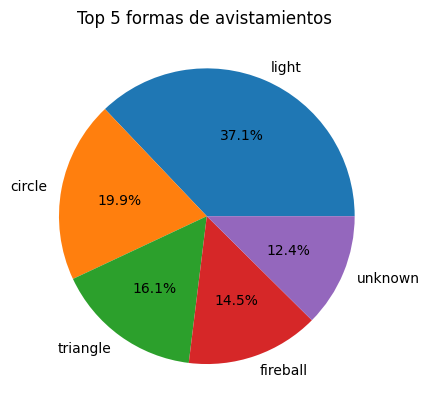

In [ ]:
# Gráfico de torta
top_formas.set_index('shape').plot.pie(y='Formas', autopct='%1.1f%%', legend=False)
plt.title('Top 5 formas de avistamientos ')
plt.ylabel('')
plt.show()

### CONSULTA 2: Avistamientos por Año (Gráfico de Línea)



In [ ]:
query2 = f"""
SELECT EXTRACT(YEAR FROM date_time) AS year, COUNT(*) AS cantidad_avs
FROM `{project_id}.{dataset_id}.{table_id}`
GROUP BY year
ORDER BY year ASC
"""
df_avistamientos_por_ano = read_gbq(query2, project_id=project_id)
df_avistamientos_por_ano

Downloading: 100%|██████████|


,year,cantidad_avs
0,1969,63
1,1970,69
2,1971,44
3,1972,60
4,1973,96
5,1974,109
6,1975,129
7,1976,115
8,1977,114
9,1978,133


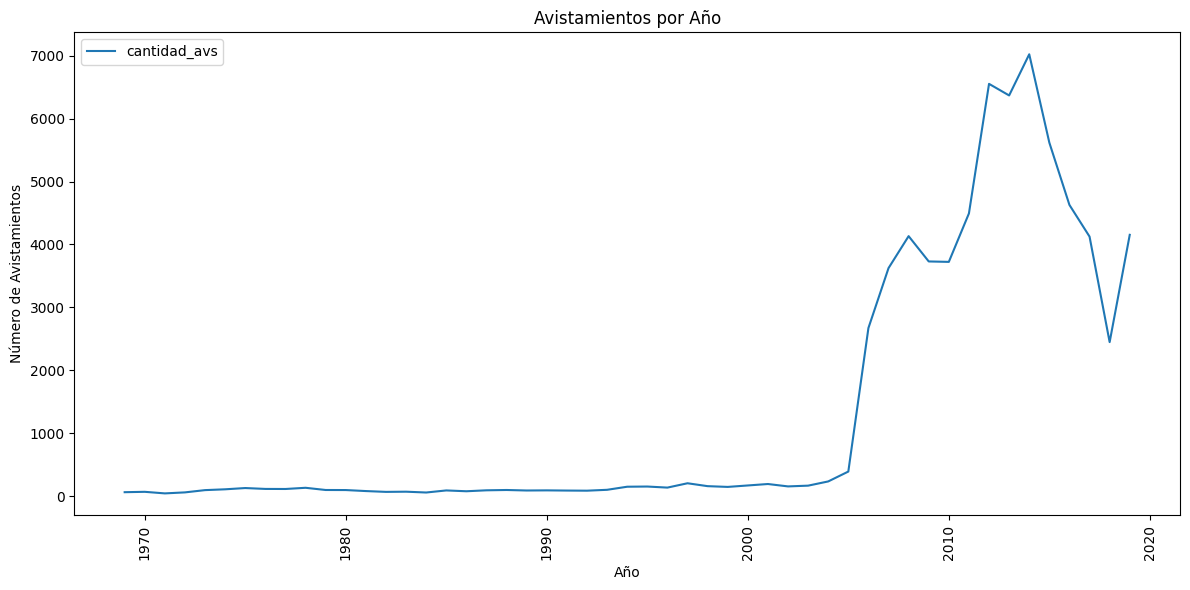

In [ ]:
df_avistamientos_por_ano.plot(kind='line', x='year', y='cantidad_avs', figsize=(12,6))
plt.title("Avistamientos por Año")
plt.xlabel("Año")
plt.ylabel("Número de Avistamientos")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### CONSULTA 3: Top 10 Estados

In [124]:
query3 = f"""
SELECT state, COUNT(*) AS estados
FROM `{project_id}.{dataset_id}.{table_id}`
GROUP BY state
ORDER BY estados DESC
LIMIT 10
"""

top_10std = read_gbq(query3, project_id=project_id)
top_10std

Downloading: 100%|██████████|


,state,estados
0,CA,8213
1,FL,4201
2,WA,3209
3,TX,2951
4,NY,2841
5,PA,2474
6,AZ,2419
7,IL,2168
8,OH,2125
9,NC,2041


### CONSULTA 4: Búsqueda de 'Firewalls'

In [ ]:
query4 = f"SELECT summary, city, state FROM `{project_id}.{dataset_id}.{table_id}` WHERE LOWER(summary) LIKE '%fireball%' LIMIT 10"
fireballs = read_gbq(query4, project_id=project_id)
print("\nReportes que mencionan 'Fireball' (Bolas de fuego):")
display(fireballs)


Downloading: 100%|██████████|

Reportes que mencionan 'Fireball' (Bolas de fuego):


,summary,city,state
0,Huge Green Fireball Dropping from sky by Lac D...,Canmore,AB
1,"Strange blue, fireball like like streaking in ...",Airdrie,AB
2,"Fireball streaks across night sky, makes right...",Edmonton,AB
3,Single orange fireball travelling across sky.,Innisfree,AB
4,Large fireball-like red/orange disc low in the...,Bethel,AK
5,"Large fireball north of Homer, Alaska. Dissip...",Homer,AK
6,"Large fireball, which dissipated upward and f...",Homer,AK
7,Short rocket-like fireball near air force base.,Anchorage,AK
8,Very large fireball with a fire trail falling ...,Anchorage,AK
9,Large fireball growing larger while coming tow...,Anchorage,AK
